# Bitwise vs logical -- exclusive vs inclusive -- across C, Verilog, CUDA
### `&` is not `&&`, and `^` (XOR) is not `|` (OR)

Two pairs of operators that look alike and behave completely differently:

- **bitwise** (`& | ^ ~`) act on **every bit in parallel**; **logical** (`&& || !`)
  collapse a whole value to one true/false. So `2 & 1 == 0` but `2 && 1` is true.
- **inclusive OR** (`|`) is 1 if **either** bit is set; **exclusive OR** (`^`) is 1
  only if the bits **differ** -- "one or the other, not both".

These are the same gates as `dgs.logic_timing`, applied to integers bit-by-bit. We
show the difference, the bit-manipulation idioms they enable, and the syntax in C,
Verilog, and CUDA. Civilian education.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import bitwise as bw
print("ready")

ready


## 1. Bitwise vs logical -- the `&` / `&&` trap

Bitwise combines two numbers bit by bit; logical asks only "is each one nonzero?".

In [2]:
a, b = 0b1011, 0b0110
print(f"a = {a:04b} ({a}),  b = {b:04b} ({b})")
print(f"  a & b  = {bw.bit_and(a,b):04b}   bitwise AND (1 where both 1)")
print(f"  a | b  = {bw.bit_or(a,b):04b}   bitwise OR  (1 where either 1)")
print(f"  a ^ b  = {bw.bit_xor(a,b):04b}   bitwise XOR (1 where they differ)")
print(f"  ~a     = {bw.bit_not(a,4):04b}   bitwise NOT (4-bit)")
print(f"\nTHE TRAP: 2 & 1 = {2 & 1}  (bitwise: 10 AND 01 = 00)")
print(f"          2 && 1 = {bw.logical_and(2,1)}  (logical: both nonzero -> true)")

a = 1011 (11),  b = 0110 (6)
  a & b  = 0010   bitwise AND (1 where both 1)
  a | b  = 1111   bitwise OR  (1 where either 1)
  a ^ b  = 1101   bitwise XOR (1 where they differ)
  ~a     = 0100   bitwise NOT (4-bit)

THE TRAP: 2 & 1 = 0  (bitwise: 10 AND 01 = 00)
          2 && 1 = 1  (logical: both nonzero -> true)


## 2. Exclusive OR vs inclusive OR (the truth tables)

The four two-input gates over $(a,b)$. **OR and XOR agree everywhere except $(1,1)$**:
inclusive OR says 1 (either is set), exclusive OR says 0 (both set = not 'one or the
other').

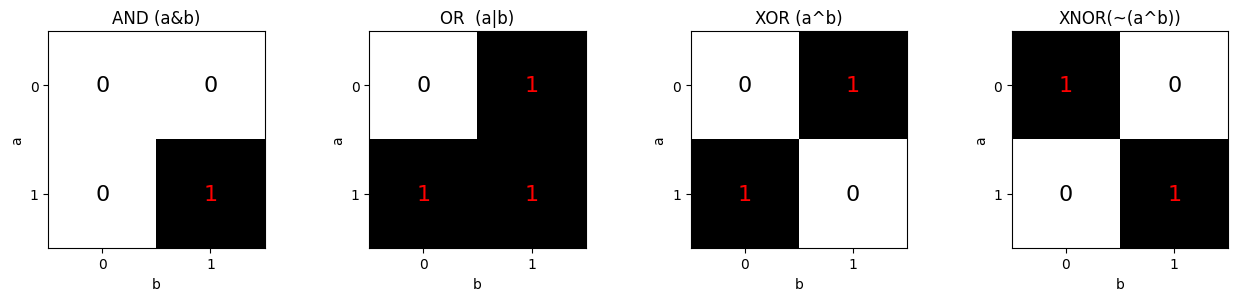

OR vs XOR differ ONLY at (a,b)=(1,1):  1|1=1  but  1^1=0


In [3]:
gates = {"AND (a&b)": bw.bit_and, "OR  (a|b)": bw.bit_or,
         "XOR (a^b)": bw.bit_xor, "XNOR(~(a^b))": lambda a,b: bw.bit_xnor(a,b,1)}
fig, ax = plt.subplots(1, 4, figsize=(13, 3))
for k, (name, fn) in enumerate(gates.items()):
    T = np.array([[fn(a,b) for b in (0,1)] for a in (0,1)])
    ax[k].imshow(T, cmap="Greys", vmin=0, vmax=1)
    for i in (0,1):
        for j in (0,1):
            ax[k].text(j, i, T[i,j], ha="center", va="center",
                       color="red" if T[i,j] else "black", fontsize=16)
    ax[k].set(title=name, xticks=[0,1], yticks=[0,1], xlabel="b", ylabel="a")
plt.tight_layout(); plt.show()
print("OR vs XOR differ ONLY at (a,b)=(1,1):  1|1=1  but  1^1=0")

## 3. Bit-manipulation idioms (why bitwise exists)

Bitwise lets you address individual bits with one-hot masks `1<<n`:
**set** (`|`), **clear** (`& ~`), **toggle** (`^`), **test** (`>> &1`). Toggling is
XOR with a mask -- do it twice and you are back where you started.

In [4]:
x = 0b0000
for op, desc in [(lambda v: bw.set_bit(v,1), "set bit 1"),
                 (lambda v: bw.set_bit(v,3), "set bit 3"),
                 (lambda v: bw.toggle_bit(v,1), "toggle bit 1"),
                 (lambda v: bw.clear_bit(v,3), "clear bit 3")]:
    x = op(x); print(f"  {desc:14s} -> {x:04b}")
print(f"\npopcount(1011) = {bw.popcount(0b1011)} ones;  parity = {bw.parity(0b1011)} (odd)")
print("shifts: 5<<1 =", 5<<1, "(x2);  20>>2 =", 20>>2, "(/4) -- the barrel shifter")

  set bit 1      -> 0010
  set bit 3      -> 1010
  toggle bit 1   -> 1000
  clear bit 3    -> 0000

popcount(1011) = 3 ones;  parity = 1 (odd)
shifts: 5<<1 = 10 (x2);  20>>2 = 5 (/4) -- the barrel shifter


## 4. Syntax across C, Verilog, and CUDA

| operation | C | Verilog | CUDA |
|---|---|---|---|
| bitwise AND | `a & b` | `a & b` | `a & b` |
| **logical** AND | `a && b` | `a && b` | `a && b` |
| inclusive OR | `a \| b` | `a \| b` | `a \| b` |
| **exclusive** OR (XOR) | `a ^ b` | `a ^ b` | `a ^ b` |
| XNOR | `~(a ^ b)` | `a ~^ b` or `a ^~ b` | `~(a ^ b)` |
| bitwise NOT | `~a` | `~a` | `~a` |
| logical NOT | `!a` | `!a` | `!a` |
| shift | `a << n`, `a >> n` | `a << n` | `a << n` |
| count 1-bits | `__builtin_popcount(a)` | `$countones(a)` (SV) | `__popc(a)` |
| parity (XOR all bits) | `__builtin_parity(a)` | `^a` (reduction) | `__popc(a) & 1` |

Verilog has a trick C lacks: **unary reduction operators** -- `&a` ANDs all bits of
`a` together, `|a` ORs them, `^a` XORs them (the parity). CUDA exposes hardware
intrinsics like `__popc` that count bits in a single instruction.

## 5. Parity = XOR of every bit (error detection)

XOR's "1 if an odd number of inputs are 1" makes it the **parity** gate: append one
parity bit and a single bit-flip in transit flips the parity, flagging the error.
This is XOR doing real work -- and it is `^a` in Verilog, one instruction.

In [5]:
for word in (0b1011, 0b1001, 0b1111):
    # parity as the running XOR of the bits == bw.parity
    xacc = 0
    for i in range(4):
        xacc ^= bw.test_bit(word, i)
    print(f"  {word:04b}: popcount={bw.popcount(word)}  parity(^bits)={xacc}  "
          f"({'odd -> parity bit 1' if xacc else 'even -> parity bit 0'})")
print("\na single flipped bit changes the parity -> the receiver detects the error")

  1011: popcount=3  parity(^bits)=1  (odd -> parity bit 1)
  1001: popcount=2  parity(^bits)=0  (even -> parity bit 0)
  1111: popcount=4  parity(^bits)=0  (even -> parity bit 0)

a single flipped bit changes the parity -> the receiver detects the error


## Takeaway

1. **Bitwise (`& | ^ ~`) act per bit; logical (`&& || !`) act on the whole value.**
   `2 & 1 == 0`, `2 && 1` is true -- mixing them up is a classic bug.
2. **Inclusive OR (`|`) vs exclusive OR (`^`)** differ only at $(1,1)$: either-set vs
   differ. XOR is addition mod 2 and the parity/error-detection gate.
3. **Masks `1<<n`** give set/clear/toggle/test; toggle is XOR (self-inverse).
4. The **syntax is nearly identical** in C/Verilog/CUDA; Verilog adds reduction
   operators (`^a`) and CUDA adds bit intrinsics (`__popc`).

Same gates as `dgs.logic_timing`, now down at the bit level. Civilian education.